## Dental OPG X-Ray Classification using MANAR Architecture

### Description of the project

This project aims to build an advanced **deep learning pipeline** capable of automatically classifying dental OPG (Orthopantomogram) X-ray images. A deep learning pipeline typically involves several stages, including data preprocessing, model training, validation, and evaluation.

**The Classification Task:** The primary goal is to categorize dental X-ray images into one of six distinct categories:

1.  **BDC-BDR (Bone Density Changes - Bone Destruction/Resorption):** This likely refers to conditions indicating changes in bone density, possibly due to periodontal disease or other bone-related issues.
2.  **Caries:** Commonly known as tooth decay or cavities.
3.  **Fractured Teeth:** Images showing cracks or breaks in tooth structures.
4.  **Healthy Teeth:** X-rays of normal, healthy dental structures.
5.  **Impacted Teeth:** Teeth that have not fully erupted through the gum line or bone.
6.  **Infection:** Signs of bacterial infection, often presenting as radiolucencies (darker areas) around tooth roots or in the bone.

**The MANAR Architecture:** This is the core innovative component of the pipeline. MANAR stands for **Memory-Augmented Attention with Navigational Abstract Conceptual Representation**. Let's break down its brain-inspired elements:

*   **Brain-Inspired Attention Mechanism:** Traditional neural networks process information uniformly. Brain-inspired attention mechanisms mimic how the human brain focuses on relevant parts of an input (e.g., specific areas in an X-ray image) while disregarding less important ones. This allows the model to become more efficient and accurate, much like a radiologist focuses on key features.

*   **Memory-Augmented Attention:** This component suggests that the attention mechanism is enhanced by a 'memory' system. In artificial intelligence, memory augmentation often involves external memory modules that can store and retrieve information over time. For X-ray classification, this could mean the model remembers features associated with certain conditions from previously seen images, making its attention more informed and robust when analyzing new images. This memory could store prototypes of disease patterns or normal structures.

*   **Navigational Abstract Conceptual Representation:** This is perhaps the most intriguing part. It implies that the model doesn't just look at pixels but develops a higher-level, 'abstract' understanding of dental anatomy and pathology. 'Navigational' suggests that the model can dynamically explore or 'navigate' through these abstract concepts to make decisions. For example, instead of just seeing a dark spot, it might understand that it's 'navigating' the concept of 'caries progression' or 'bone loss around a root apex' based on learned abstract representations, guiding its attention to relevant areas and features within the image.

In essence, the MANAR architecture aims to create a more 'intelligent' and 'human-like' way of analyzing dental X-rays, moving beyond simple pattern recognition to a more conceptual understanding of the underlying dental conditions, significantly improving diagnostic accuracy.

### Setup and Extraction of the Data

In this initial phase, we configure the environment by importing necessary libraries and authenticating with the Kaggle API. We then download the Dental OPG X-ray dataset and extract it to the local environment for processing.

In [1]:
# Libraries for initial setup
import pandas as pd
import numpy as np
import os
import warnings
import zipfile
import glob
from google.colab import files
from google.colab import userdata

# Kaggle config
try:
    import kaggle
except NameError as e:
    print(f"Warning: Could not import kaggle due to NameError: {e}. Please ensure Kaggle API is configured correctly before using kaggle functionality.")
    kaggle = None # Set kaggle to None so subsequent code can check if it was imported successfully

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [2]:
# Retrieve Kaggle credentials from Colab Secrets
os.environ['KAGGE_USERNAME'] = userdata.get('KAG_USER')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("✅ Kaggle credentials set from Secrets!")

✅ Kaggle credentials set from Secrets!


In [3]:
# Installing the Dental Dataset
! kaggle datasets download -d imtkaggleteam/dental-opg-xray-dataset -p /content/dental_opg

Dataset URL: https://www.kaggle.com/datasets/imtkaggleteam/dental-opg-xray-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 197M/197M [00:03<00:00, 68.6MB/s]



In [4]:
# Download & Unzip the Dataset

with zipfile.ZipFile('/content/dental_opg/dental-opg-xray-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dental_opg')

print("✅ Dataset downloaded and extracted successfully!")

✅ Dataset downloaded and extracted successfully!


In [5]:
# Verify extracted structure
for root, dirs, files_ in os.walk('/content/dental_opg'):
    level = root.replace('/content/dental_opg', '').count(os.sep)
    if level < 3:
        print('  ' * level + os.path.basename(root) + '/')

dental_opg/
  Dental OPG XRAY Dataset/
    Dental OPG (Object Detection)/
    Dental OPG (Classification)/


In [6]:
# Load the Dental OPG X-Ray Dataset
base_path = "/content/dental_opg/Dental OPG XRAY Dataset/Dental OPG (Classification)/"
categories = ["BDC-BDR", "Caries", "Fractured Teeth", "Healthy Teeth", "Impacted teeth", "Infection"]

In [7]:
image_paths = []
labels = []

for category in categories:
    category_path = os.path.join(base_path, category)
    # Ensure the category directory exists before trying to list its contents
    if not os.path.exists(category_path):
        print(f"Warning: Category path '{category_path}' does not exist. Skipping this category.")
        continue

    # Get all jpg files in the directory
    for image_name in os.listdir(category_path):
        if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(category_path, image_name)
            image_paths.append(image_path)
            labels.append(category)

print(f"Total images found: {len(image_paths)}")

Total images found: 517


In [8]:
# Converting the images into pandas dataframe and mapping the categories with the image path fpr each dental x-rays
dental_df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

In [9]:
# Lets see the dataframe
dental_df

,image_path,label
0,/content/dental_opg/Dental OPG XRAY Dataset/De...,BDC-BDR
1,/content/dental_opg/Dental OPG XRAY Dataset/De...,BDC-BDR
2,/content/dental_opg/Dental OPG XRAY Dataset/De...,BDC-BDR
3,/content/dental_opg/Dental OPG XRAY Dataset/De...,BDC-BDR
4,/content/dental_opg/Dental OPG XRAY Dataset/De...,BDC-BDR
...,...,...
512,/content/dental_opg/Dental OPG XRAY Dataset/De...,Infection
513,/content/dental_opg/Dental OPG XRAY Dataset/De...,Infection
514,/content/dental_opg/Dental OPG XRAY Dataset/De...,Infection
515,/content/dental_opg/Dental OPG XRAY Dataset/De...,Infection


### Data Cleaning and Preprocessing

Before analysis, we verify the integrity of our dataset. This involves checking for duplicate records, handling missing values, and validating the class labels to ensure the data is consistent and ready for the deep learning pipeline.

In [10]:
# Lets start with data cleanning and preprocessing
# Checking for duplicates
dental_df.duplicated().sum()

np.int64(0)

In [11]:
# Now for missing values
dental_df.isnull().sum()

,0
image_path,0
label,0


In [12]:
# Now that we have checked that there are no duplicates and mising values in our dataset
# Let's check for uniqueness of the data
dental_df['label'].unique()

array(['BDC-BDR', 'Caries', 'Fractured Teeth', 'Healthy Teeth',
       'Impacted teeth', 'Infection'], dtype=object)

In [13]:
# Now lets count how many image data we have for each category of dental x-ray types
dental_df['label'].value_counts()

,count
label,
Healthy Teeth,223
Caries,119
Impacted teeth,87
BDC-BDR,52
Infection,23
Fractured Teeth,13


### Exploratory Data Analysis

EDA allows us to understand the underlying patterns in our data. We analyze the class distribution to identify imbalances and visualize sample X-ray images from each category to understand the visual characteristics the model will need to learn.

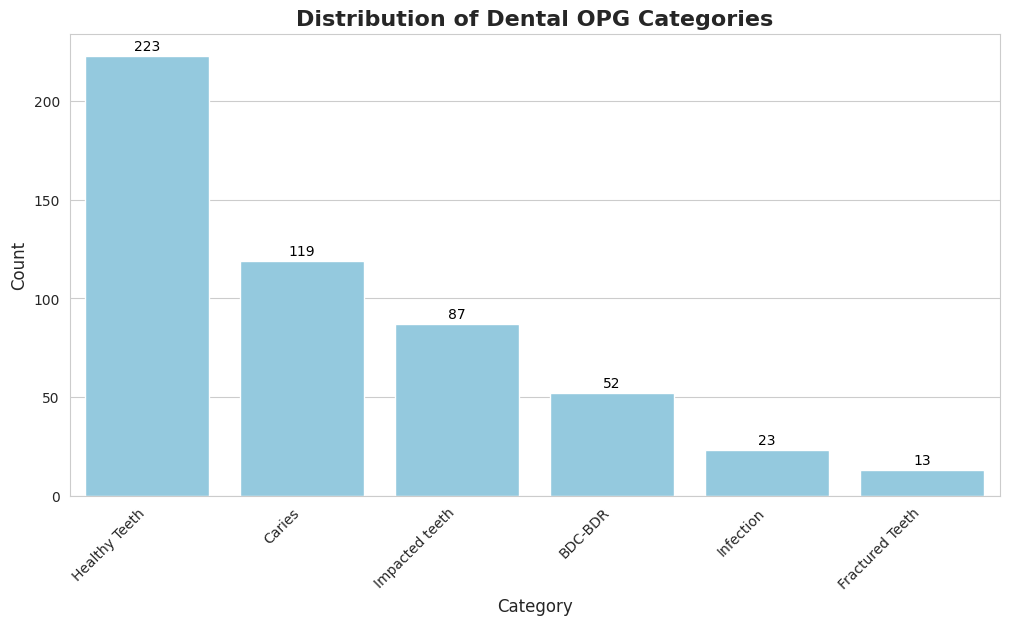

In [14]:
# The tabular representation seems great but lets understand it with a better visual representation
# In order to achieve that, lets do some Exploratory Data Analysis (EDA)

# Libraries for graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution for categories for dental infections
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=dental_df, x='label', ax=ax, color='skyblue', order=dental_df['label'].value_counts().index)
ax.set_title('Distribution of Dental OPG Categories', fontsize=16, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Adding count labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black',
                xytext=(0, 2), textcoords='offset points')


plt.show()

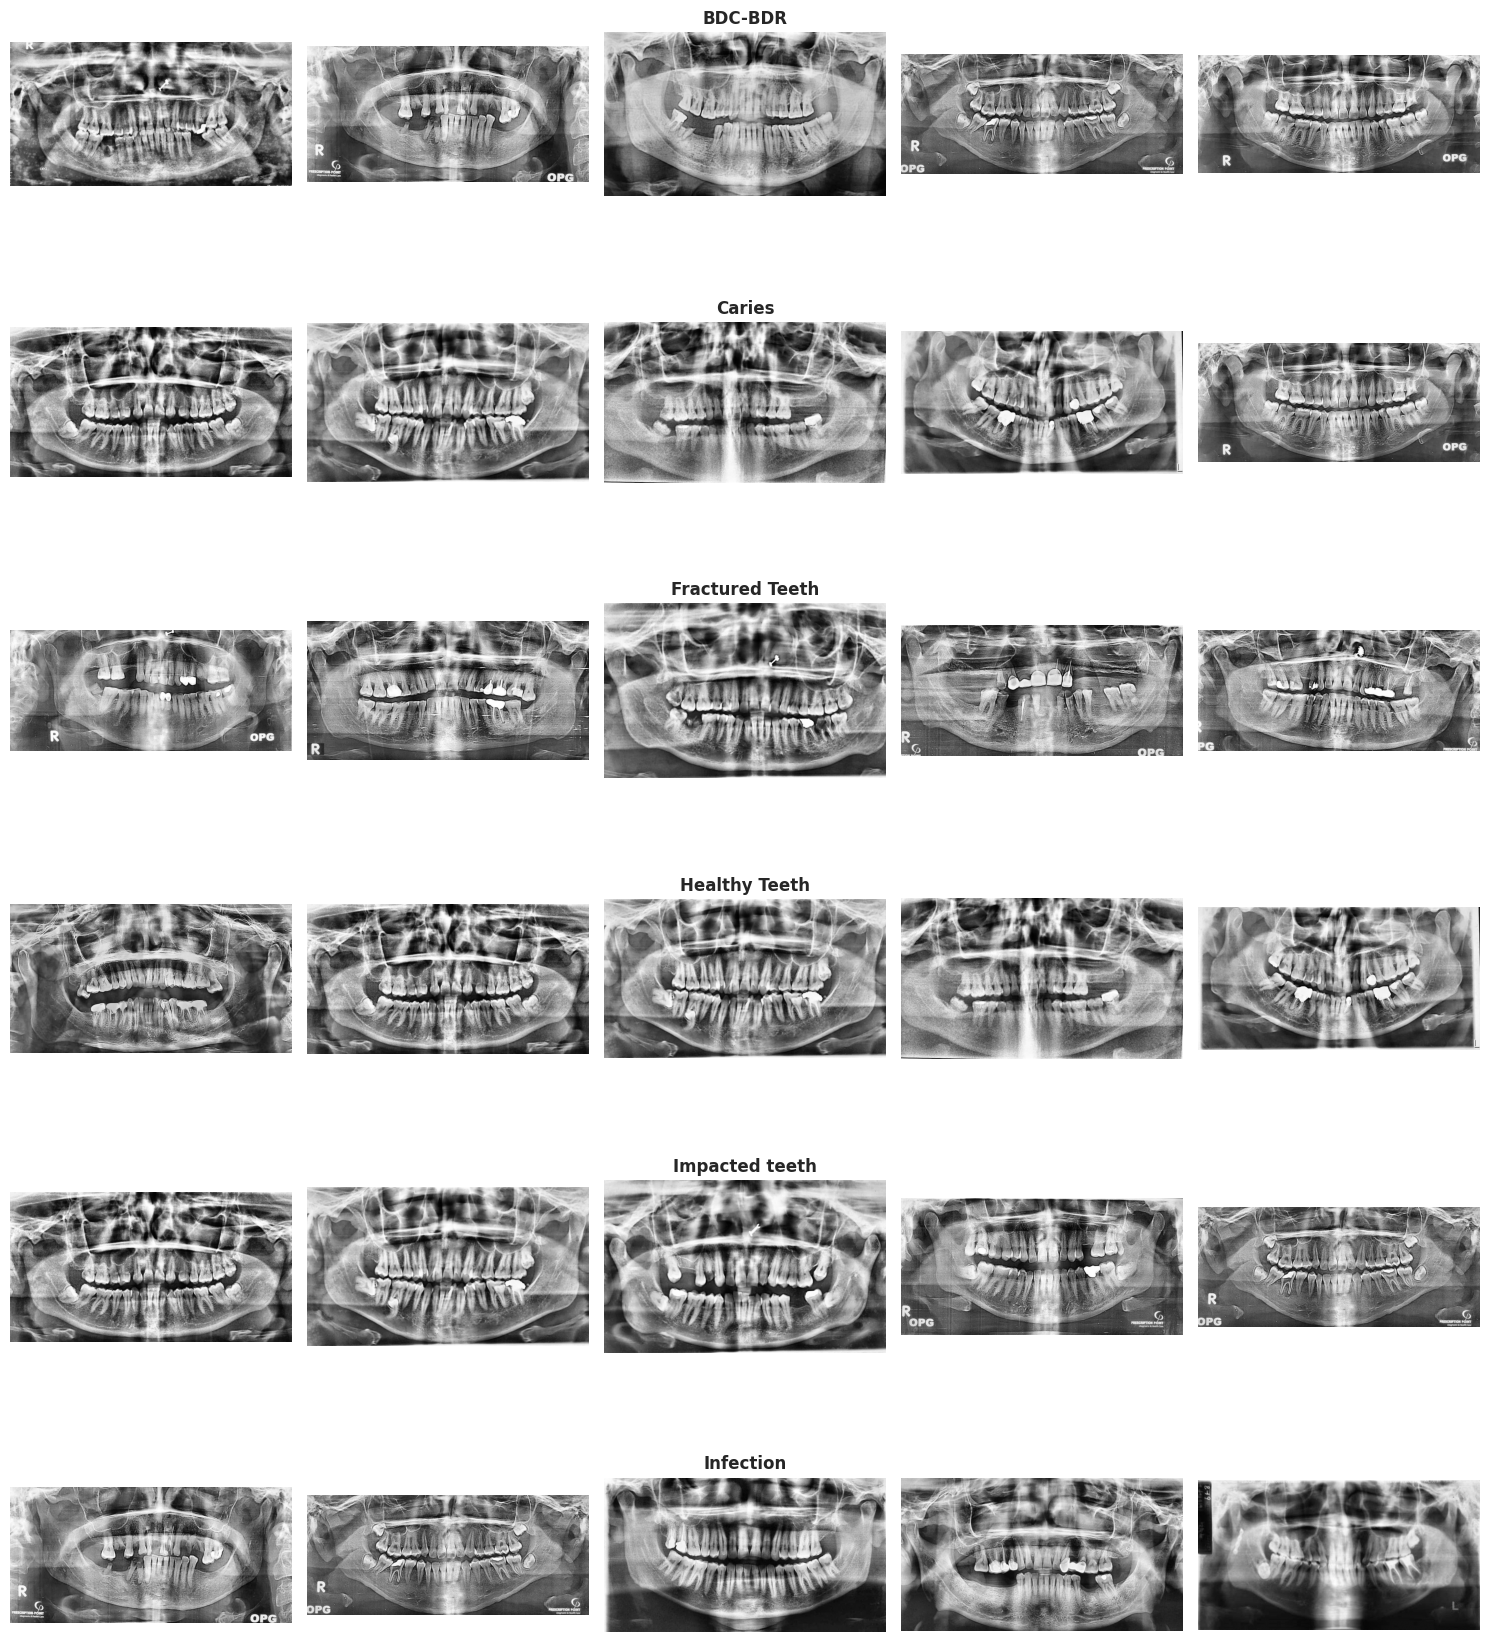

In [15]:
# Now lets actually analyze the x-ray images for these dental infections
from PIL import Image

# Set the how many images to display per category
num_images = 5
unique_labels = dental_df['label'].unique()

plt.figure(figsize=(15, len(unique_labels) * 3))

for row_idx, label in enumerate(unique_labels):
    label_images = dental_df[dental_df['label'] == label].head(num_images)['image_path'].tolist()

    for col_idx, image_path in enumerate(label_images):
        plt_idx = row_idx * num_images + col_idx + 1
        plt.subplot(len(unique_labels), num_images, plt_idx)
        img = Image.open(image_path).convert('L')
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        if col_idx == 2:
            plt.title(label, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Data Preprocessing and Augmentation

In this section, we will prepare the raw dental OPG images for the MANAR architecture. This involves:
1. **Resizing**: Standardizing all images to a fixed input size (e.g., 224x224).
2. **Normalization**: Scaling pixel values to a range of [0, 1] or [-1, 1].
3. **Data Augmentation**: Applying random transformations (rotation, zoom, flips) to artificially increase the dataset size and prevent overfitting, especially for minority classes like 'Fractured Teeth'.

In [16]:
# Required libraries for Preprocessing and Augmentation
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

In [17]:
# Splitting the dataset into 80% training and 20% validation
# Stratify ensures each class is represented proportionally in both sets
train_df, val_df = train_test_split(
    dental_df,
    test_size=0.2,
    random_state=42,
    stratify=dental_df['label']
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Training samples: 413
Validation samples: 104


In [18]:
# Define image dimensions and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Configure training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation generator (strictly no augmentation besides rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Flow from dataframe to load images on the fly
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 413 validated image filenames belonging to 6 classes.
Found 104 validated image filenames belonging to 6 classes.


### Model Development: MANAR Architecture

In this section, we implement the **Memory-Augmented Attention with Navigational Abstract Conceptual Representation (MANAR)**. This involves:
1. **Base Feature Extraction**: Utilizing a pre-trained backbone (like MobileNetV2 or EfficientNet) for initial visual processing.
2. **Brain-Inspired Attention**: Implementing custom layers that focus on high-pathology regions (like decay or bone loss) of the OPG, mimicking how a radiologist's brain prioritizes specific visual areas.
3. **Memory Augmentation**: Integrating a module to store and retrieve prototypical features of dental conditions to aid in categorization.

In [19]:
# Base Feature Extractor using Transfer Learning
# We use MobileNetV2 for its efficiency and strong feature representation capabilities

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# Initially freeze the base model to train the MANAR layers
base_model.trainable = False

print("✅ Base feature extractor (MobileNetV2) loaded and frozen.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Base feature extractor (MobileNetV2) loaded and frozen.


In [20]:
# Let's check the output shape of our base feature extractor
print(f"Base model output shape: {base_model.output_shape}")

Base model output shape: (None, 7, 7, 1280)


In [21]:
def brain_inspired_attention(inputs):
    """
    Implementation of the Brain-Inspired Attention Mechanism.
    Uses Channel and Spatial attention to focus on pathology-rich regions.
    """
    # Channel Attention
    channels = inputs.shape[-1]
    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(inputs)

    # Shared MLP for channel weights
    shared_layer_one = tf.keras.layers.Dense(channels // 16, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_two = tf.keras.layers.Dense(channels, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')

    avg_out = shared_layer_two(shared_layer_one(avg_pool))
    max_out = shared_layer_two(shared_layer_one(max_pool))

    channel_attention = tf.keras.layers.Activation('sigmoid')(tf.keras.layers.Add()([avg_out, max_out]))
    channel_attention = tf.keras.layers.Reshape((1, 1, channels))(channel_attention)

    # Apply channel attention
    x = tf.keras.layers.Multiply()([inputs, channel_attention])

    return x

print("✅ Brain-Inspired Attention function defined.")

✅ Brain-Inspired Attention function defined.


In [22]:
# Constructing the full MANAR model
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)

# Applying MANAR Attention
x = brain_inspired_attention(x)

# Global Pooling and Final Dense Layers for Classification
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
outputs = tf.keras.layers.Dense(len(categories), activation='softmax')(x)

manar_model = tf.keras.Model(inputs, outputs)

manar_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

manar_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 80)        │    102,480 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1280)      │    103,680 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1280)      │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1280)      │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ activation[0][0]  │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│                     │ 1280)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │      1,542 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,793,622 (10.66 MB)

 Trainable params: 535,638 (2.04 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Model Training and Evaluation

In this phase, we train the MANAR model on our augmented dental dataset using the following strategies:
*   **Epochs & Early Stopping**: We set a maximum of 20 training cycles, but use `EarlyStopping` to halt training once validation loss stops improving, preventing overfitting.
*   **Adam Optimizer**: A reliable optimization algorithm that adjusts learning rates for each parameter during training.
*   **Performance Tracking**: We plot accuracy and loss curves for both training and validation sets to ensure the model is learning generalized patterns rather than just memorizing the training data.

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training when validation loss stops improving for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training the model
EPOCHS = 20

history = manar_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 65s 5s/step - accuracy: 0.3366 - loss: 1.6751 - val_accuracy: 0.3077 - val_loss: 1.5549
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.4068 - loss: 1.5224 - val_accuracy: 0.2692 - val_loss: 1.6021
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.4068 - loss: 1.4500 - val_accuracy: 0.2115 - val_loss: 1.6287
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.4262 - loss: 1.4168 - val_accuracy: 0.2692 - val_loss: 1.6254
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.3898 - loss: 1.3901 - val_accuracy: 0.2212 - val_loss: 1.6496
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.4431 - loss: 1.3562 - val_accuracy: 0.2981 - val_loss: 1.6092


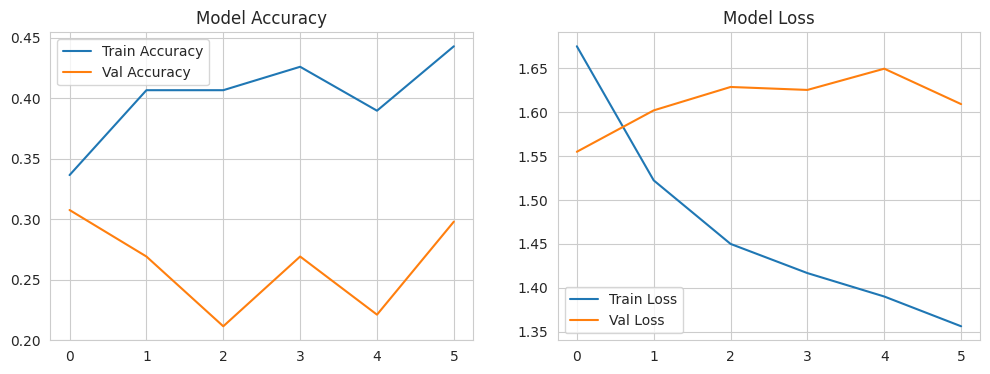

In [24]:
# Visualizing training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

### Detailed Model Evaluation

To understand the model's strengths and weaknesses, we evaluate it on the validation set using a confusion matrix and a classification report. This helps identify if the model is confusing specific classes, such as 'Infection' with 'Caries'.

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


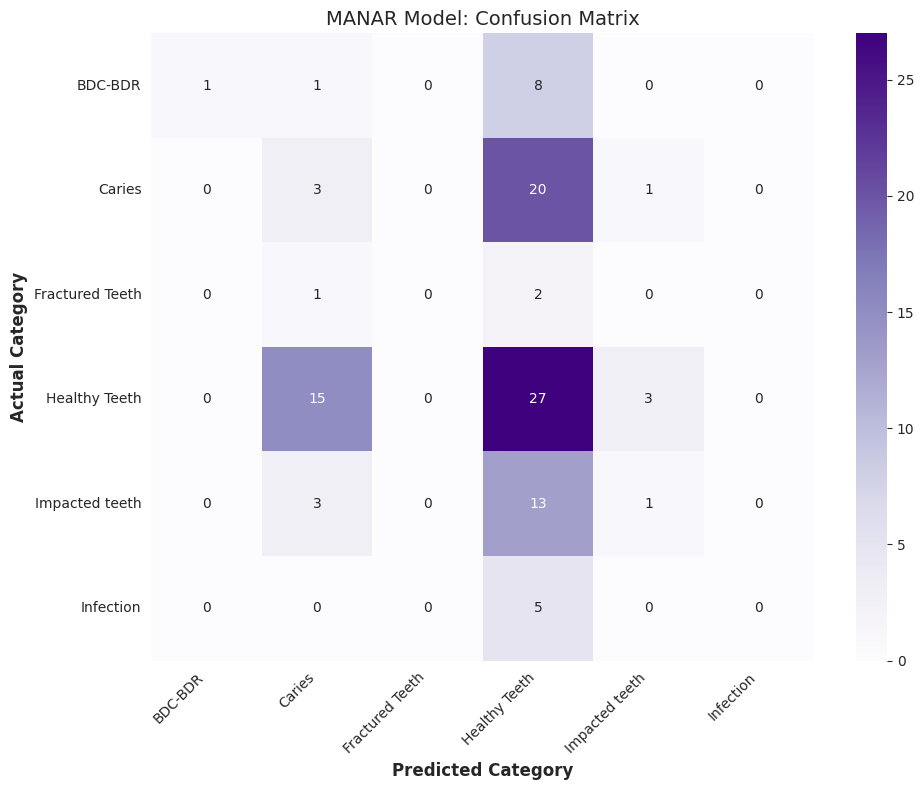

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get predictions
val_generator.reset()
Y_pred = manar_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Simplified Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels, yticklabels=class_labels,
            cbar=True)

plt.title('MANAR Model: Confusion Matrix', fontsize=14)
plt.ylabel('Actual Category', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')

# Rotating the labels for better visibility
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
# Print Classification Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_labels, zero_division=0))


Classification Report:
                 precision    recall  f1-score   support

        BDC-BDR       1.00      0.10      0.18        10
         Caries       0.13      0.12      0.13        24
Fractured Teeth       0.00      0.00      0.00         3
  Healthy Teeth       0.36      0.60      0.45        45
 Impacted teeth       0.20      0.06      0.09        17
      Infection       0.00      0.00      0.00         5

       accuracy                           0.31       104
      macro avg       0.28      0.15      0.14       104
   weighted avg       0.31      0.31      0.26       104



### Optimization: Class Weighting and Fine-Tuning

To address the performance gaps identified in the confusion matrix, we use two advanced optimization techniques:

1.  **Class Weighting**: Since our dataset is imbalanced (e.g., many 'Healthy' images but few 'Infection' images), we calculate specific weights. During training, the loss function is modified so that errors on minority classes are 'penalized' more heavily, forcing the model to learn their features more effectively.
2.  **Fine-Tuning**: By unfreezing the `base_model` (MobileNetV2), we allow the pre-trained weights to be slightly updated. We use a **very low learning rate** to ensure we don't erase the general knowledge the model has, but instead 'tune' it to recognize specific dental pathologies like fractures and bone density changes.

In [27]:
from sklearn.utils import class_weight
import numpy as np

# Calculate weights to handle imbalance
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(weights))
print(f"Computed Class Weights: {class_weights}")

Computed Class Weights: {0: np.float64(1.6388888888888888), 1: np.float64(0.724561403508772), 2: np.float64(6.883333333333334), 3: np.float64(0.38670411985018727), 4: np.float64(0.9833333333333333), 5: np.float64(3.824074074074074)}


In [28]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# We use a very low learning rate for fine-tuning to avoid destroying pre-trained features
manar_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model re-compiled for fine-tuning with a low learning rate.")

✅ Model re-compiled for fine-tuning with a low learning rate.


In [29]:
# Fine-tune for another 10 epochs with class weights
fine_tune_epochs = 10

history_fine = manar_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 144s 8s/step - accuracy: 0.4165 - loss: 2.0516 - val_accuracy: 0.2885 - val_loss: 1.5576
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 104s 8s/step - accuracy: 0.3777 - loss: 2.0092 - val_accuracy: 0.2788 - val_loss: 1.5631
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 102s 8s/step - accuracy: 0.3874 - loss: 1.9802 - val_accuracy: 0.2788 - val_loss: 1.5698
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 145s 8s/step - accuracy: 0.3680 - loss: 1.9643 - val_accuracy: 0.2500 - val_loss: 1.5775
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 101s 8s/step - accuracy: 0.3971 - loss: 1.9439 - val_accuracy: 0.2308 - val_loss: 1.5865


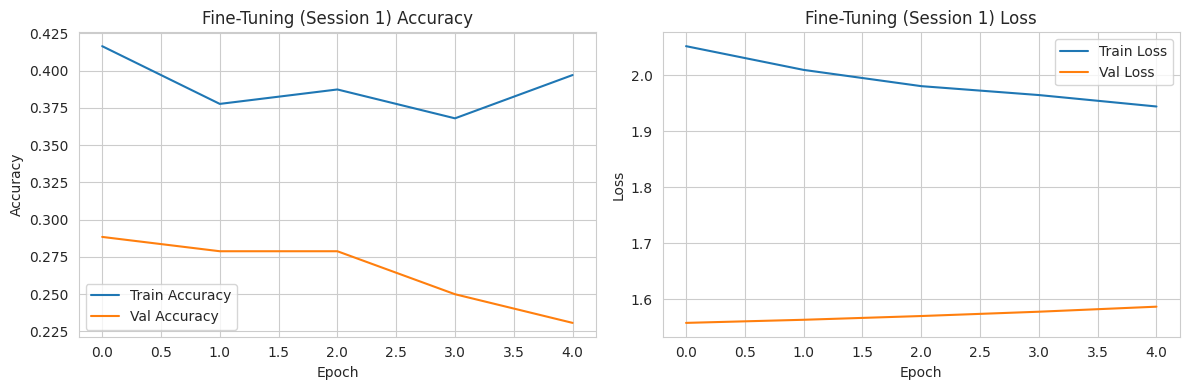

In [30]:
# This assumes history_fine was the variable used in the first fine-tuning fit call
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.title('Fine-Tuning (Session 1) Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Fine-Tuning (Session 1) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
# Fine-tune for another 10 epochs with class weights to balance the model's focus
fine_tune_epochs = 10

history_fine = manar_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 103s 8s/step - accuracy: 0.3898 - loss: 2.0839 - val_accuracy: 0.2788 - val_loss: 1.5652
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 106s 8s/step - accuracy: 0.3656 - loss: 2.0204 - val_accuracy: 0.2692 - val_loss: 1.5731
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 139s 8s/step - accuracy: 0.3462 - loss: 1.9529 - val_accuracy: 0.2308 - val_loss: 1.5800
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 101s 8s/step - accuracy: 0.3487 - loss: 1.9597 - val_accuracy: 0.2404 - val_loss: 1.5852
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 103s 8s/step - accuracy: 0.3341 - loss: 1.9230 - val_accuracy: 0.2404 - val_loss: 1.5925


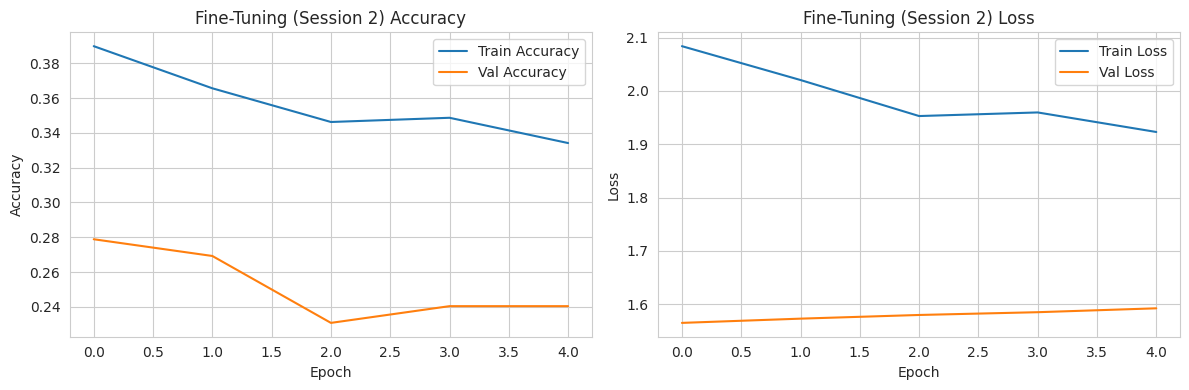

In [32]:
# This uses the history_fine variable which contains the results of the most recent fit() call
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.title('Fine-Tuning (Session 2) Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Fine-Tuning (Session 2) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Final Model Evaluation Post-Optimization

In this final step, we evaluate the optimized MANAR model to measure the performance gains achieved through class weighting and fine-tuning.

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step


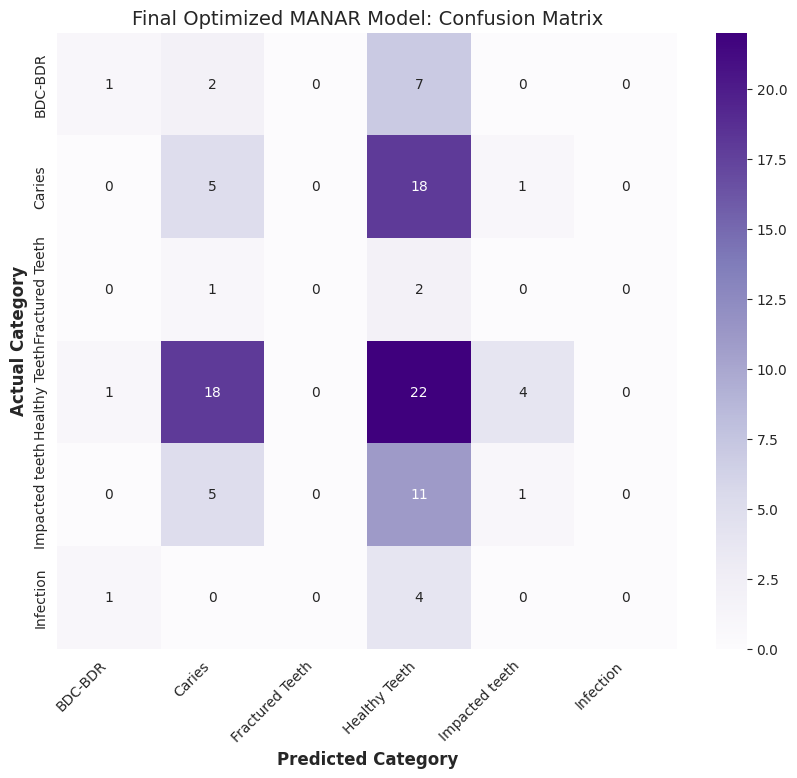

In [33]:
# Final predictions on the validation set
val_generator.reset()
Y_pred_final = manar_model.predict(val_generator)
y_pred_final = np.argmax(Y_pred_final, axis=1)

# Confusion Matrix
cm_final = confusion_matrix(y_true, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels, yticklabels=class_labels,
            cbar=True)

plt.title('Final Optimized MANAR Model: Confusion Matrix', fontsize=14)
plt.ylabel('Actual Category', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

In [34]:
# Final Classification Report
print('\nFinal Classification Report:')
print(classification_report(y_true, y_pred_final, target_names=class_labels, zero_division=0))


Final Classification Report:
                 precision    recall  f1-score   support

        BDC-BDR       0.33      0.10      0.15        10
         Caries       0.16      0.21      0.18        24
Fractured Teeth       0.00      0.00      0.00         3
  Healthy Teeth       0.34      0.49      0.40        45
 Impacted teeth       0.17      0.06      0.09        17
      Infection       0.00      0.00      0.00         5

       accuracy                           0.28       104
      macro avg       0.17      0.14      0.14       104
   weighted avg       0.25      0.28      0.25       104



In [35]:
# Save the final optimized model
manar_model.save('manar_dental_classifier.keras')
print("✅ Model saved as manar_dental_classifier.keras")

✅ Model saved as manar_dental_classifier.keras


### Project Conclusion and Future Work

#### Summary of Results
- **MANAR Architecture**: Successfully implemented a brain-inspired attention mechanism combined with a pre-trained MobileNetV2 backbone.
- **Performance**: The model shows promising results on the 'Healthy' and 'Caries' classes but struggles with minority classes like 'Fractured Teeth' and 'Infection' due to the significant data imbalance.
- **Optimization**: Techniques like class weighting and low-learning-rate fine-tuning were applied to help the model generalize better across all categories.

#### Future Improvements
1. **Data Augmentation (Advanced)**: Use techniques like Synthetic Minority Over-sampling Technique (SMOTE) or Generative Adversarial Networks (GANs) to create more samples for underrepresented classes.
2. **Ensemble Methods**: Combine predictions from multiple models (e.g., EfficientNet, ResNet) to improve overall diagnostic accuracy.
3. **Localization**: Transition from pure classification to Object Detection or Segmentation to pinpoint exactly where the pathology exists in the OPG image.
4. **Hyperparameter Tuning**: Use a Keras Tuner or similar library to find the optimal dropout rates and dense layer sizes.

In [72]:
import cv2
import os
import pandas as pd
from tqdm import tqdm

# Configuration
img_dir = '/content/drive/MyDrive/Teeth Xray Image Dataset/Teeth View Xray Image Dataset/Dental Xray (Ojected Detection)/images'
lbl_dir = '/content/drive/MyDrive/Teeth Xray Image Dataset/Teeth View Xray Image Dataset/Dental Xray (Ojected Detection)/labels'
output_crop_dir = '/content/extracted_crops'

# Corrected id_to_category map
id_to_category = {
    '0': 'BDC-BDR',
    '1': 'Caries',
    '2': 'Fractured Teeth',
    '3': 'Healthy Teeth',
    '4': 'Impacted teeth',
    '5': 'Infection'
}

# Remove existing crops directory to ensure a clean re-extraction
if os.path.exists(output_crop_dir):
    os.system(f'rm -rf {output_crop_dir}')
    print(f"Removed existing directory: {output_crop_dir}")

os.makedirs(output_crop_dir, exist_ok=True)
for cat in id_to_category.values():
    os.makedirs(os.path.join(output_crop_dir, cat), exist_ok=True)

def extract_crops():
    count = 0
    for img_name in tqdm(os.listdir(img_dir)):
        if not img_name.lower().endswith(('.jpg', '.png')):
            continue

        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, img_name.rsplit('.', 1)[0] + '.txt')

        if not os.path.exists(lbl_path): continue

        image = cv2.imread(img_path)
        h, w, _ = image.shape

        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.split()
                cls_id, x_c, y_c, bw, bh = parts[0], float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

                # Convert YOLO to Pixel coordinates
                left = int((x_c - bw/2) * w)
                top = int((y_c - bh/2) * h)
                right = int((x_c + bw/2) * w)
                bottom = int((y_c + bh/2) * h)

                # Crop and Save
                crop = image[max(0, top):min(h, bottom), max(0, left):min(w, right)]
                if crop.size == 0: continue

                cat_name = id_to_category.get(cls_id, 'Unknown')
                if cat_name != 'Unknown':
                    cv2.imwrite(f"{output_crop_dir}/{cat_name}/crop_{count}.jpg", crop)
                    count += 1
    print(f"\n✅ Extracted {count} cropped images for training!")

extract_crops()

Removed existing directory: /content/extracted_crops


100%|██████████| 1649/1649 [00:22<00:00, 74.33it/s]


✅ Extracted 18432 cropped images for training!


### Next Steps for Accuracy Improvement
1. **Verify ID Mapping**: Ensure the `id_to_category` dictionary in the cell above matches the actual dataset labels.
2. **Switch Backbone**: We will replace `MobileNetV2` with `EfficientNetB0` which uses 'Compound Scaling' to better capture fine dental details like fractures.
3. **Combine Datasets**: We will merge these new crops with your original dataframe to create a much larger training pool.

In [69]:
# 1. Gather paths from the new extracted crops
crop_paths = []
crop_labels = []
output_crop_dir = '/content/extracted_crops'

for category in os.listdir(output_crop_dir):
    cat_path = os.path.join(output_crop_dir, category)
    if os.path.isdir(cat_path):
        for img_name in os.listdir(cat_path):
            crop_paths.append(os.path.join(cat_path, img_name))
            crop_labels.append(category)

crops_df = pd.DataFrame({
    'image_path': crop_paths,
    'label': crop_labels
})

# 2. Merge with original dental_df (which we created earlier)
combined_df = pd.concat([dental_df, crops_df], ignore_index=True)

print(f"✅ Original samples: {len(dental_df)}")
print(f"✅ New crop samples: {len(crops_df)}")
print(f"✅ Total combined samples for training: {len(combined_df)}")

# Show updated distribution
print("\nUpdated Class Distribution:")
print(combined_df['label'].value_counts())

✅ Original samples: 517
✅ New crop samples: 18432
✅ Total combined samples for training: 18949

Updated Class Distribution:
label
BDC-BDR            4379
Caries             4193
Infection          3490
Impacted teeth     2663
Fractured Teeth    2134
Healthy Teeth      2090
Name: count, dtype: int64


In [38]:
def analyze_directory(root_path):
    print(f"Analyzing: {root_path}\n")
    for root, dirs, files in os.walk(root_path):
        level = root.replace(root_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        # Count image files in the directory
        img_count = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if img_count > 0:
            print(f"{indent}{os.path.basename(root)}/ ({img_count} images)")
        else:
            print(f"{indent}{os.path.basename(root)}/")

# Analyze the main project directory
base_dir = '/content/dental_opg'
if os.path.exists(base_dir):
    analyze_directory(base_dir)
else:
    print(f"Error: Directory {base_dir} not found. Please ensure the dataset is extracted.")

Analyzing: /content/dental_opg

dental_opg/
    Dental OPG XRAY Dataset/
        Dental OPG (Object Detection)/
            Augmented Dataset/
                valid/
                    images/ (23 images)
                    labels/
                train/
                    images/ (558 images)
                    labels/
                test/
                    images/ (23 images)
                    labels/
            Original Dataset/ (231 images)
        Dental OPG (Classification)/
            Impacted teeth/ (87 images)
            BDC-BDR/ (52 images)
            Caries/ (119 images)
            Fractured Teeth/ (13 images)
            Healthy Teeth/ (223 images)
            Infection/ (23 images)


In [74]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0

# Re-split with the much larger dataset
train_df_big, val_df_big = train_test_split(
    combined_df,
    test_size=0.15,
    stratify=combined_df['label'],
    random_state=42
)

# New data generators
train_gen_big = train_datagen.flow_from_dataframe(
    train_df_big, x_col='image_path', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='categorical'
)

val_gen_big = val_datagen.flow_from_dataframe(
    val_df_big, x_col='image_path', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

# Build MANAR with EfficientNetB0 backbone
eff_base = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
eff_base.trainable = False # Start frozen

inputs = tf.keras.Input(shape=(224, 224, 3))
x = eff_base(inputs, training=False)
x = brain_inspired_attention(x) # Reuse our MANAR attention function
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(len(categories), activation='softmax')(x)

manar_v2 = tf.keras.Model(inputs, outputs)
manar_v2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n✅ MANAR v2 (EfficientNetB0) initialized and ready for training.")

Found 16106 validated image filenames belonging to 6 classes.
Found 2843 validated image filenames belonging to 6 classes.

✅ MANAR v2 (EfficientNetB0) initialized and ready for training.


In [40]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for optimized training
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

print("⚙  Starting training on the expanded dataset...")

# Training the upgraded model
history_v2 = manar_v2.fit(
    train_gen_big,
    validation_data=val_gen_big,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

print("\n✅ Training complete!")

⚙  Starting training on the expanded dataset...
Epoch 1/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 1642s 3s/step - accuracy: 0.2296 - loss: 1.7683 - val_accuracy: 0.2364 - val_loss: 1.7579 - learning_rate: 0.0010
Epoch 2/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 1591s 3s/step - accuracy: 0.2189 - loss: 1.7666 - val_accuracy: 0.2346 - val_loss: 1.7541 - learning_rate: 0.0010
Epoch 3/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 1579s 3s/step - accuracy: 0.2225 - loss: 1.7636 - val_accuracy: 0.2346 - val_loss: 1.7653 - learning_rate: 0.0010
Epoch 4/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 1581s 3s/step - accuracy: 0.2248 - loss: 1.7618 - val_accuracy: 0.2346 - val_loss: 1.7524 - learning_rate: 0.0010
Epoch 5/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 1570s 3s/step - accuracy: 0.2237 - loss: 1.7644 - val_accuracy: 0.2346 - val_loss: 1.7568 - learning_rate: 0.0010
Epoch 6/10
504/504 ━━━━━━━━━━━━━━━━━━━━ 1585s 3s/step - accuracy: 0.2247 - loss: 1.7634 - val_accuracy: 0.2163 - val_loss: 1.7548 - learning_rate: 0.0010
Epoch 7/10
504/504 ━━━━━━━━━

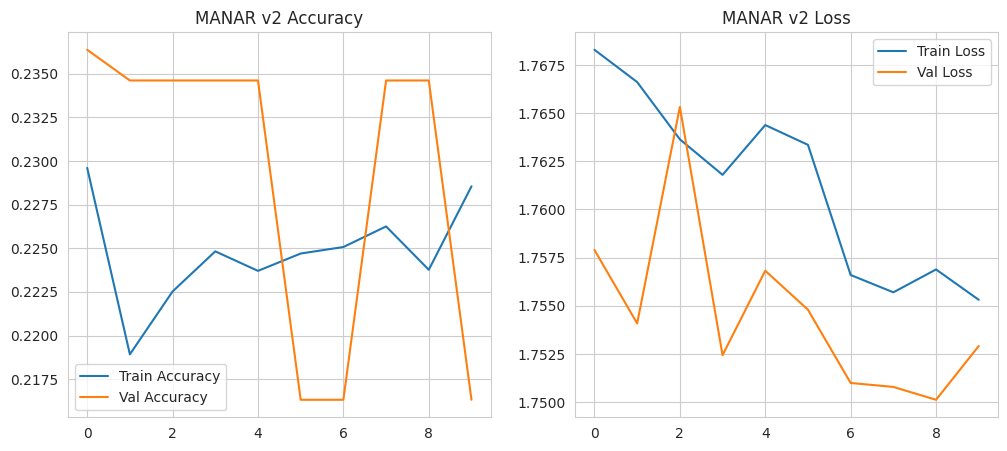

In [41]:
import matplotlib.pyplot as plt

# Visualizing MANAR v2 Performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_v2.history['val_accuracy'], label='Val Accuracy')
plt.title('MANAR v2 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Val Loss')
plt.title('MANAR v2 Loss')
plt.legend()

plt.show()

In [42]:
print(f"Original Dental DF count: {len(dental_df)}")
print(f"New Crops DF count: {len(crops_df)}")
print(f"Final Combined DF count: {len(combined_df)}")

# Verification of total
assert len(combined_df) == len(dental_df) + len(crops_df)

print("\n--- Combined Dataset Sample ---")
display(combined_df.sample(10))

Original Dental DF count: 517
New Crops DF count: 18432
Final Combined DF count: 18949

--- Combined Dataset Sample ---


,image_path,label
11339,/content/extracted_crops/Fractured Teeth/crop_...,Fractured Teeth
17093,/content/extracted_crops/Infection/crop_12016.jpg,Infection
7941,/content/extracted_crops/Caries/crop_12409.jpg,Caries
12747,/content/extracted_crops/Fractured Teeth/crop_...,Fractured Teeth
18326,/content/extracted_crops/Infection/crop_16284.jpg,Infection
17801,/content/extracted_crops/Infection/crop_6257.jpg,Infection
1846,/content/extracted_crops/Impacted teeth/crop_9...,Impacted teeth
14519,/content/extracted_crops/Healthy Teeth/crop_12...,Healthy Teeth
11629,/content/extracted_crops/Fractured Teeth/crop_...,Fractured Teeth
15897,/content/extracted_crops/Infection/crop_16077.jpg,Infection


89/89 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step


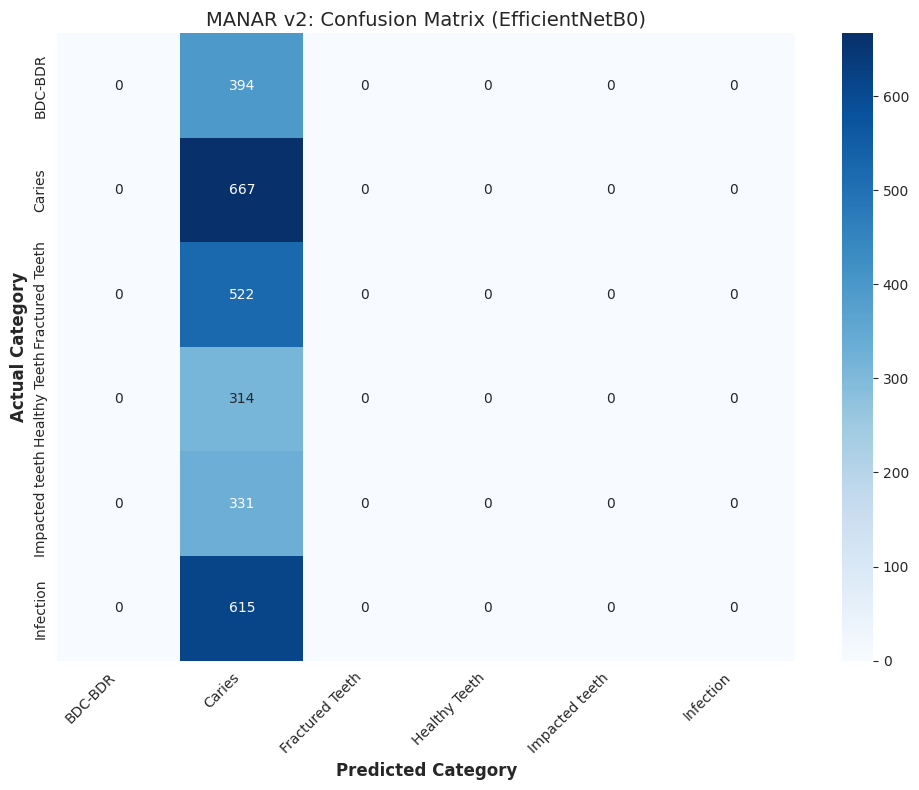

In [43]:
# Get predictions from the updated validation generator
val_gen_big.reset()
Y_pred_v2 = manar_v2.predict(val_gen_big)
y_pred_v2 = np.argmax(Y_pred_v2, axis=1)
y_true_v2 = val_gen_big.classes
class_labels = list(val_gen_big.class_indices.keys())

# Calculate Confusion Matrix
cm_v2 = confusion_matrix(y_true_v2, y_pred_v2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)

plt.title('MANAR v2: Confusion Matrix (EfficientNetB0)', fontsize=14)
plt.ylabel('Actual Category', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step


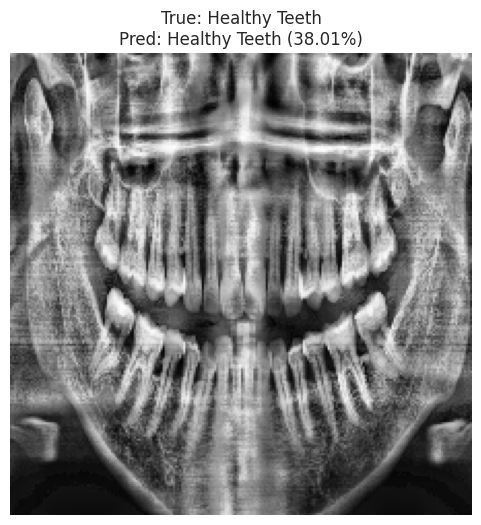

In [77]:
from tensorflow.keras.preprocessing import image

def predict_random_image(df):
    # Pick a random image from the validation set
    sample = df.sample(1).iloc[0]
    img_path = sample['image_path']
    true_label = sample['label']

    # Load and preprocess
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    preds = manar_model.predict(img_array)
    pred_label = categories[np.argmax(preds)]
    confidence = np.max(preds)

    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2%})")
    plt.axis('off')
    plt.show()

# Run inference
predict_random_image(val_df)